In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")   # keep the lab output clean

# A single seed used everywhere for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Nicer default plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

import sklearn
print("scikit-learn :", sklearn.__version__)
print("pandas       :", pd.__version__)
print("numpy        :", np.__version__)
print("\nSetup complete")

scikit-learn : 1.5.2
pandas       : 2.2.2
numpy        : 1.24.4

Setup complete


In [4]:
from sklearn.datasets import load_diabetes, load_breast_cancer

# ---- Regression dataset: diabetes ----
diabetes = load_diabetes(as_frame=True)
X_reg = diabetes.data          # features (already scaled in this dataset)
y_reg = diabetes.target        # CONTINUOUS target: disease progression after 1 year

# ---- Classification dataset: breast cancer ----
cancer = load_breast_cancer(as_frame=True)
X_clf = cancer.data            # 30 features measured from cell images
y_clf = cancer.target          # CATEGORICAL target: 0 = malignant, 1 = benign

print("REGRESSION  -> X_reg:", X_reg.shape, "| y_reg dtype:", y_reg.dtype)
print("CLASSIFY    -> X_clf:", X_clf.shape, "| y_clf dtype:", y_clf.dtype)

REGRESSION  -> X_reg: (442, 10) | y_reg dtype: float64
CLASSIFY    -> X_clf: (569, 30) | y_clf dtype: int64


In [5]:
# Peek at the regression target: many different real numbers -> CONTINUOUS
print("Regression target (first 8 values):")
print(y_reg.head(8).tolist())
print("min =", y_reg.min(), " max =", y_reg.max(), " unique values =", y_reg.nunique())

print("\nClassification target value counts (only two labels exist):")
print(y_clf.value_counts())
print("Label meaning:", dict(enumerate(cancer.target_names)))  # 0->malignant, 1->benign

Regression target (first 8 values):
[151.0, 75.0, 141.0, 206.0, 135.0, 97.0, 138.0, 63.0]
min = 25.0  max = 346.0  unique values = 214

Classification target value counts (only two labels exist):
target
1    357
0    212
Name: count, dtype: int64
Label meaning: {0: 'malignant', 1: 'benign'}


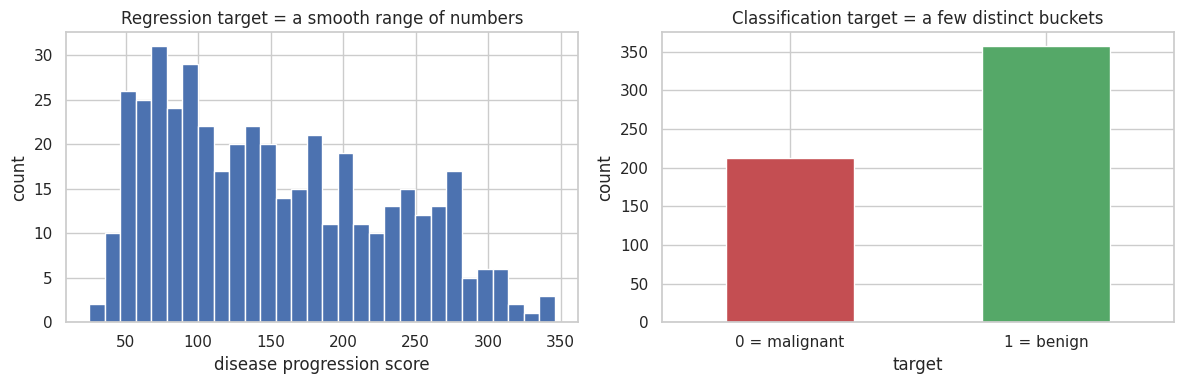

In [6]:
# Visual proof: the SHAPE of the target tells you the task type
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_reg, bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Regression target = a smooth range of numbers")
axes[0].set_xlabel("disease progression score"); axes[0].set_ylabel("count")

y_clf.value_counts().sort_index().plot(kind="bar", ax=axes[1],
                                       color=["#C44E52", "#55A868"])
axes[1].set_title("Classification target = a few distinct buckets")
axes[1].set_xticklabels(["0 = malignant", "1 = benign"], rotation=0)
axes[1].set_ylabel("count")

plt.tight_layout(); plt.show()

In [7]:
from sklearn.model_selection import train_test_split

# Regression split (80% train / 20% test)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)

# Classification split — stratify keeps the malignant/benign ratio identical in both sets
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf)

print("Regression :", Xr_train.shape[0], "train rows |", Xr_test.shape[0], "test rows")
print("Classify   :", Xc_train.shape[0], "train rows |", Xc_test.shape[0], "test rows")
print("\nClass balance preserved by stratify:")
print("  train:", yc_train.value_counts(normalize=True).round(3).to_dict())
print("  test :", yc_test.value_counts(normalize=True).round(3).to_dict())

Regression : 353 train rows | 89 test rows
Classify   : 455 train rows | 114 test rows

Class balance preserved by stratify:
  train: {1: 0.626, 0: 0.374}
  test : {1: 0.632, 0: 0.368}


In [8]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()        # 1. create
lin_reg.fit(Xr_train, yr_train)     # 2. fit
yr_pred = lin_reg.predict(Xr_test)  # 3. predict

# Compare a few predictions against the truth
compare = pd.DataFrame({
    "actual":    yr_test.values[:8].round(1),
    "predicted": yr_pred[:8].round(1)
})
compare["error"] = (compare["predicted"] - compare["actual"]).round(1)
print(compare.to_string(index=False))

 actual  predicted  error
  219.0      139.5  -79.5
   70.0      179.5  109.5
  202.0      134.0  -68.0
  230.0      291.4   61.4
  111.0      123.8   12.8
   84.0       92.2    8.2
  242.0      258.2   16.2
  272.0      181.3  -90.7


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Pipeline = scale THEN classify, treated as one model
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])

log_reg.fit(Xc_train, yc_train)               # fit scaler + model in one call
yc_pred  = log_reg.predict(Xc_test)           # hard labels: 0 or 1
yc_proba = log_reg.predict_proba(Xc_test)[:, 1]  # probability of class "1" (benign)

preview = pd.DataFrame({
    "actual_label":   yc_test.values[:8],
    "predicted_label": yc_pred[:8],
    "prob_benign":    yc_proba[:8].round(3),
})
print(preview.to_string(index=False))

 actual_label  predicted_label  prob_benign
            0                0        0.000
            1                1        1.000
            0                0        0.006
            1                1        0.534
            0                0        0.000
            1                1        0.992
            1                1        1.000
            0                0        0.000


In [10]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             root_mean_squared_error, r2_score)

mae  = mean_absolute_error(yr_test, yr_pred)
mse  = mean_squared_error(yr_test, yr_pred)
rmse = root_mean_squared_error(yr_test, yr_pred)
r2   = r2_score(yr_test, yr_pred)

print("Regression performance (Linear Regression)")
print(f"  MAE  = {mae:8.2f}   (off by ~{mae:.0f} score-points on average)")
print(f"  MSE  = {mse:8.2f}")
print(f"  RMSE = {rmse:8.2f}")
print(f"  R^2  = {r2:8.3f}   (model explains ~{r2*100:.0f}% of the variation)")

Regression performance (Linear Regression)
  MAE  =    42.79   (off by ~43 score-points on average)
  MSE  =  2900.19
  RMSE =    53.85
  R^2  =    0.453   (model explains ~45% of the variation)


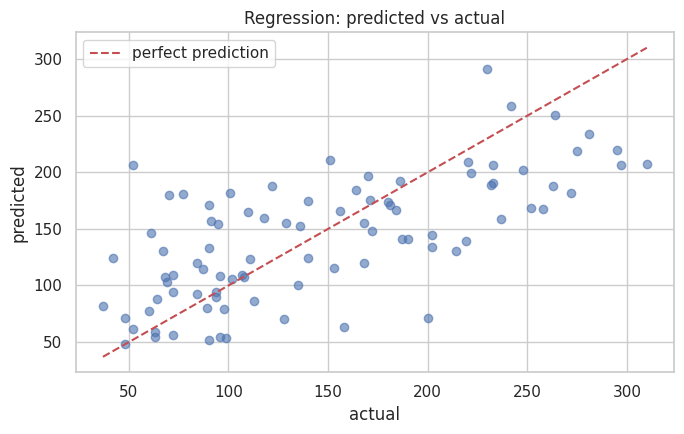

In [11]:
# A predicted-vs-actual plot: perfect predictions land on the red diagonal
plt.figure()
plt.scatter(yr_test, yr_pred, alpha=0.6, color="#4C72B0")
lims = [min(yr_test.min(), yr_pred.min()), max(yr_test.max(), yr_pred.max())]
plt.plot(lims, lims, "r--", label="perfect prediction")
plt.xlabel("actual"); plt.ylabel("predicted")
plt.title("Regression: predicted vs actual")
plt.legend(); plt.tight_layout(); plt.show()

In [12]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report)

print("Classification performance (Logistic Regression)")
print(f"  Accuracy  = {accuracy_score(yc_test, yc_pred):.3f}")
print(f"  Precision = {precision_score(yc_test, yc_pred):.3f}")
print(f"  Recall    = {recall_score(yc_test, yc_pred):.3f}")
print(f"  F1-score  = {f1_score(yc_test, yc_pred):.3f}")

print("\nFull per-class report:")
print(classification_report(yc_test, yc_pred,
                            target_names=cancer.target_names))

Classification performance (Logistic Regression)
  Accuracy  = 0.982
  Precision = 0.986
  Recall    = 0.986
  F1-score  = 0.986

Full per-class report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



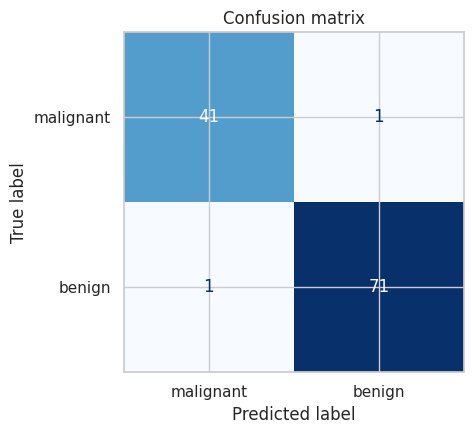

Read it as: rows = TRUE label, columns = PREDICTED label.
Diagonal = correct. Off-diagonal = mistakes.


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(yc_test, yc_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=cancer.target_names)
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion matrix"); plt.tight_layout(); plt.show()

print("Read it as: rows = TRUE label, columns = PREDICTED label.")
print("Diagonal = correct. Off-diagonal = mistakes.")

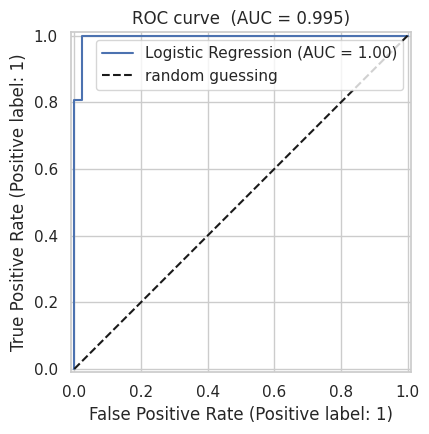

AUC = 0.995  (1.0 = perfect ranking, 0.5 = coin flip)


In [14]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

auc = roc_auc_score(yc_test, yc_proba)
RocCurveDisplay.from_predictions(yc_test, yc_proba, name="Logistic Regression")
plt.plot([0, 1], [0, 1], "k--", label="random guessing")
plt.title(f"ROC curve  (AUC = {auc:.3f})")
plt.legend(); plt.tight_layout(); plt.show()

print(f"AUC = {auc:.3f}  (1.0 = perfect ranking, 0.5 = coin flip)")

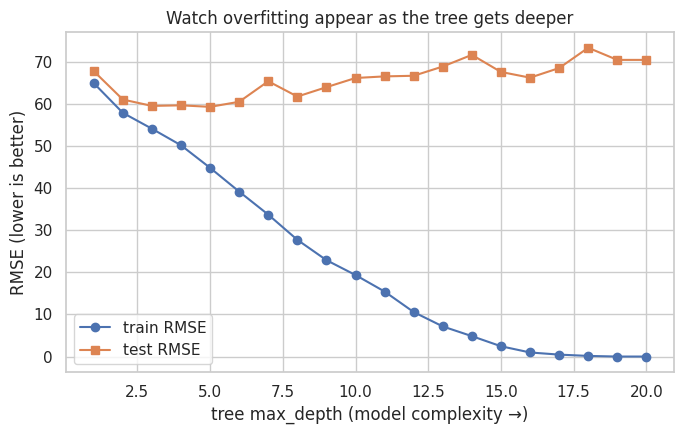

Train RMSE keeps DROPPING (memorising), but test RMSE bottoms out around depth 5
After that, the train/test GAP widens = OVERFITTING.


In [15]:
from sklearn.tree import DecisionTreeRegressor

depths = range(1, 21)
train_rmse, test_rmse = [], []

for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    tree.fit(Xr_train, yr_train)
    train_rmse.append(root_mean_squared_error(yr_train, tree.predict(Xr_train)))
    test_rmse.append(root_mean_squared_error(yr_test,  tree.predict(Xr_test)))

plt.figure()
plt.plot(depths, train_rmse, "o-", label="train RMSE")
plt.plot(depths, test_rmse,  "s-", label="test RMSE")
plt.xlabel("tree max_depth (model complexity →)")
plt.ylabel("RMSE (lower is better)")
plt.title("Watch overfitting appear as the tree gets deeper")
plt.legend(); plt.tight_layout(); plt.show()

best_d = depths[int(np.argmin(test_rmse))]
print(f"Train RMSE keeps DROPPING (memorising), but test RMSE bottoms out around depth {best_d}")
print("After that, the train/test GAP widens = OVERFITTING.")

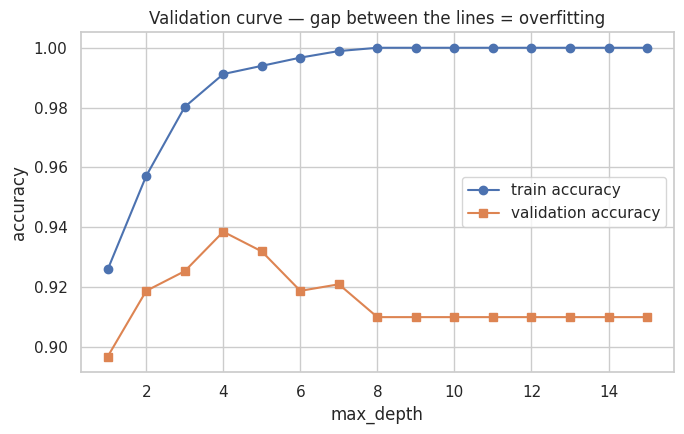

In [16]:
from sklearn.model_selection import validation_curve
from sklearn.tree import DecisionTreeClassifier

param_range = range(1, 16)
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    Xc_train, yc_train,
    param_name="max_depth", param_range=list(param_range),
    cv=5, scoring="accuracy", n_jobs=-1)

plt.figure()
plt.plot(param_range, train_scores.mean(axis=1), "o-", label="train accuracy")
plt.plot(param_range, val_scores.mean(axis=1),  "s-", label="validation accuracy")
plt.xlabel("max_depth"); plt.ylabel("accuracy")
plt.title("Validation curve — gap between the lines = overfitting")
plt.legend(); plt.tight_layout(); plt.show()

In [17]:
from sklearn.model_selection import cross_val_score

# 5-fold CV on the regression model. scoring is negative RMSE (sklearn maximises scores,
# so "better" = closer to 0). We flip the sign back to read it normally.
cv_scores = cross_val_score(LinearRegression(), Xr_train, yr_train,
                            cv=5, scoring="neg_root_mean_squared_error")
rmse_folds = -cv_scores
print("RMSE per fold :", np.round(rmse_folds, 2))
print(f"Mean RMSE     : {rmse_folds.mean():.2f}  (+/- {rmse_folds.std():.2f})")
print("\nThe +/- is your confidence: one split could have hidden this spread.")

RMSE per fold : [52.53 58.94 52.09 56.5  59.81]
Mean RMSE     : 55.97  (+/- 3.18)

The +/- is your confidence: one split could have hidden this spread.


In [18]:
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# cross_validate can report SEVERAL metrics at once
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
results = cross_validate(log_reg, Xc_train, yc_train, cv=skf, scoring=scoring)

summary = pd.DataFrame({
    m: [results[f"test_{m}"].mean(), results[f"test_{m}"].std()]
    for m in scoring
}, index=["mean", "std"]).T.round(3)
print("5-fold cross-validation of the Logistic Regression pipeline:\n")
print(summary.to_string())

5-fold cross-validation of the Logistic Regression pipeline:

            mean    std
accuracy   0.978  0.010
precision  0.979  0.016
recall     0.986  0.013
f1         0.983  0.008
roc_auc    0.996  0.005


In [19]:
from sklearn.model_selection import GridSearchCV

# Tune a Decision Tree classifier inside a scaling pipeline
tree_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

param_grid = {
    "clf__max_depth":        [2, 3, 4, 5, 6, 8, None],
    "clf__min_samples_leaf": [1, 3, 5, 10],
}

grid = GridSearchCV(tree_pipe, param_grid, cv=5,
                    scoring="f1", n_jobs=-1, return_train_score=True)
grid.fit(Xc_train, yc_train)

print("Combinations tried :", len(grid.cv_results_["params"]))
print("Best hyperparameters:", grid.best_params_)
print(f"Best CV F1 score    : {grid.best_score_:.3f}")

Combinations tried : 28
Best hyperparameters: {'clf__max_depth': 4, 'clf__min_samples_leaf': 1}
Best CV F1 score    : 0.951


In [20]:
# Inspect the top 5 combinations to see how the search reasoned
res = pd.DataFrame(grid.cv_results_)
top = (res.sort_values("rank_test_score")
          .loc[:, ["param_clf__max_depth", "param_clf__min_samples_leaf",
                   "mean_test_score", "std_test_score", "mean_train_score"]]
          .head(5)
          .rename(columns={"param_clf__max_depth": "max_depth",
                           "param_clf__min_samples_leaf": "min_samples_leaf",
                           "mean_test_score": "cv_f1",
                           "std_test_score": "cv_f1_std",
                           "mean_train_score": "train_f1"}))
print("Top 5 hyperparameter combinations:\n")
print(top.round(3).to_string(index=False))
print("\nNote how train_f1 near 1.0 with a lower cv_f1 signals overfitting for deep trees.")

Top 5 hyperparameter combinations:

max_depth  min_samples_leaf  cv_f1  cv_f1_std  train_f1
        4                 1  0.951      0.014     0.993
        5                 5  0.950      0.015     0.981
        8                 3  0.950      0.010     0.985
        5                 3  0.950      0.010     0.985
     None                 3  0.950      0.010     0.985

Note how train_f1 near 1.0 with a lower cv_f1 signals overfitting for deep trees.


In [21]:
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": log_reg,
    "Single Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest":        RandomForestClassifier(n_estimators=300,
                                                   random_state=RANDOM_STATE, n_jobs=-1),
}

rows = []
for name, model in models.items():
    s = cross_val_score(model, Xc_train, yc_train, cv=skf, scoring="f1")
    rows.append({"model": name, "cv_f1_mean": s.mean(), "cv_f1_std": s.std()})

leaderboard = pd.DataFrame(rows).sort_values("cv_f1_mean", ascending=False)
print("Model comparison (5-fold CV, F1 score):\n")
print(leaderboard.round(3).to_string(index=False))

Model comparison (5-fold CV, F1 score):

               model  cv_f1_mean  cv_f1_std
 Logistic Regression       0.983      0.008
       Random Forest       0.972      0.014
Single Decision Tree       0.932      0.014


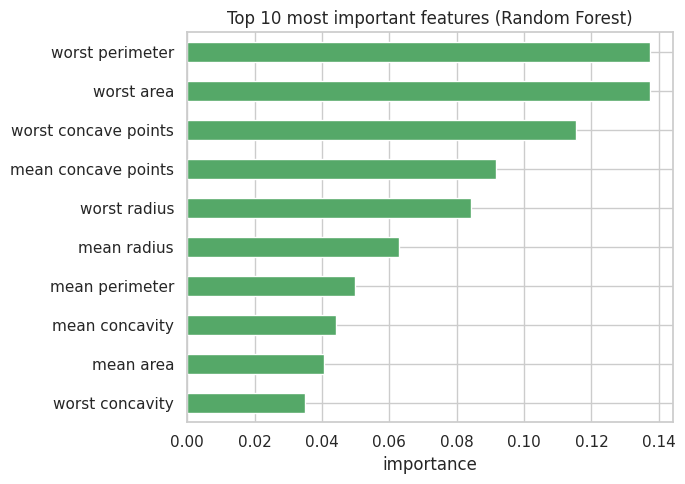

In [22]:
# Which measurements does the forest rely on most? -> feature importances
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(Xc_train, yc_train)

importances = (pd.Series(rf.feature_importances_, index=X_clf.columns)
                 .sort_values(ascending=False).head(10))

plt.figure(figsize=(7, 5))
importances.sort_values().plot(kind="barh", color="#55A868")
plt.title("Top 10 most important features (Random Forest)")
plt.xlabel("importance"); plt.tight_layout(); plt.show()

In [23]:
# 1 + 2 : Pipeline tuned with GridSearchCV
final_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

final_grid = {
    "clf__n_estimators":     [200, 400],
    "clf__max_depth":        [4, 6, None],
    "clf__min_samples_leaf": [1, 2, 4],
}

final_search = GridSearchCV(final_pipe, final_grid, cv=skf,
                            scoring="f1", n_jobs=-1)
final_search.fit(Xc_train, yc_train)

best_model = final_search.best_estimator_
print("Chosen hyperparameters:", final_search.best_params_)
print(f"Cross-validated F1 (training data): {final_search.best_score_:.3f}")

Chosen hyperparameters: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}
Cross-validated F1 (training data): 0.970


================ FINAL HELD-OUT TEST RESULTS ================
  Accuracy  : 0.956
  Precision : 0.959
  Recall    : 0.972
  F1-score  : 0.966
  ROC-AUC   : 0.993


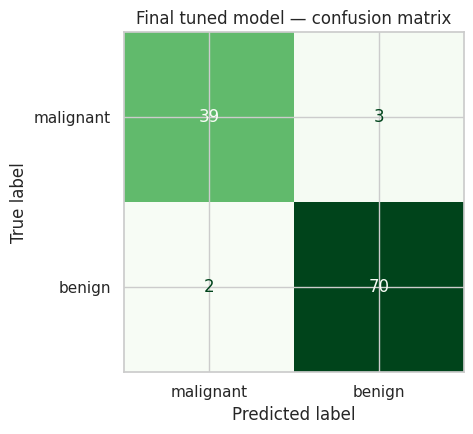

In [24]:
# 3 : Open the vault — evaluate ONCE on the untouched test set
final_pred  = best_model.predict(Xc_test)
final_proba = best_model.predict_proba(Xc_test)[:, 1]

print("================ FINAL HELD-OUT TEST RESULTS ================")
print(f"  Accuracy  : {accuracy_score(yc_test, final_pred):.3f}")
print(f"  Precision : {precision_score(yc_test, final_pred):.3f}")
print(f"  Recall    : {recall_score(yc_test, final_pred):.3f}")
print(f"  F1-score  : {f1_score(yc_test, final_pred):.3f}")
print(f"  ROC-AUC   : {roc_auc_score(yc_test, final_proba):.3f}")
print("============================================================")

ConfusionMatrixDisplay(confusion_matrix(yc_test, final_pred),
                       display_labels=cancer.target_names).plot(cmap="Greens", colorbar=False)
plt.title("Final tuned model — confusion matrix"); plt.tight_layout(); plt.show()

In [25]:
# 4 : Save the model, then reload it and predict — this is how models go to production
import joblib

joblib.dump(best_model, "final_model.joblib")
print("Model saved to final_model.joblib")

reloaded = joblib.load("final_model.joblib")
sample = Xc_test.iloc[[0]]
pred_label = reloaded.predict(sample)[0]
print("\nReloaded model predicts on one new sample:",
      cancer.target_names[pred_label],
      f"(actual: {cancer.target_names[yc_test.iloc[0]]})")
print("\nDeliverable complete: a tuned, cross-validated, saved predictive model.")

Model saved to final_model.joblib

Reloaded model predicts on one new sample: malignant (actual: malignant)

Deliverable complete: a tuned, cross-validated, saved predictive model.
